# Module 5: Generating a One-Million-Scan Training Dataset

---

In this module, we take the forward model from Module 4 and run it at scale to generate 1 million simulated detector scans for training the 1D-CNN.

**Learning Objectives:**
- Design a physically meaningful parameter space for (T, P, $\chi$)
- Parallelize scan generation with `multiprocessing`
- Write results incrementally to HDF5 for memory efficiency
- Benchmark local vs. cloud CPU performance
- Normalize the dataset for neural network training

**Deliverable:** A `dataset_1M.h5` file containing 1M simulated scans ready for training.

---

## Setup: Imports and Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time
import multiprocessing as mp
import os
import contextlib
import platform
from pathlib import Path
from functools import partial
from tqdm.notebook import tqdm

# Import HAPI
import hapi

# ── Project paths ──────────────────────────────────────────
PROJECT_DIR = Path.home() / "RedwoodLabs" / "methane-ml-course"
DATA_DIR    = PROJECT_DIR / 'data'
HITRAN_DIR  = DATA_DIR / 'hitran'
SPECTRA_DIR = DATA_DIR / 'spectra'
DATASET_DIR = DATA_DIR / 'datasets'
OUTPUT_DIR  = PROJECT_DIR / 'outputs'

for d in [DATA_DIR, HITRAN_DIR, SPECTRA_DIR, DATASET_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── HITRAN parameters ──────────────────────────────────────
MOLECULE_ID  = 6
ISOTOPE_ID   = 1
TABLE_NAME   = 'CH4_4383_4386'
NU_MIN       = 4383.0     # cm⁻¹
NU_MAX       = 4386.0     # cm⁻¹
NU_STEP      = 0.001      # cm⁻¹
PATH_LENGTH  = 100.0      # cm

# Initialize HITRAN database
hapi.db_begin(str(HITRAN_DIR))

# ── Plotting defaults ──────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

print(f"System       : {platform.system()} {platform.machine()}")
print(f"CPU cores    : {mp.cpu_count()}")
print(f"Project dir  : {PROJECT_DIR}")
print(f"Dataset dir  : {DATASET_DIR}")
print("\n✅ All imports successful!")

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
@contextlib.contextmanager
def suppress_stdout():
    """
    Context manager to suppress stdout and stderr.
    Used to silence HAPI's verbose output during spectrum generation.
    Must be defined at the top level so worker processes can access it via fork.
    """
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            yield

print("✅ suppress_stdout() defined")


✅ suppress_stdout() defined


### Forward Model Functions (from Modules 3 & 4)

We bring forward the core functions from previous modules:
- `generate_absorbance_spectrum()` — HITRAN/HAPI Voigt calculation (Module 3)
- `build_nu_scan()` — Nonlinear wavenumber mapping (Module 4)
- `simulate_detector_scan_fast()` — Vectorized full forward model (Module 4)

In [3]:
def generate_absorbance_spectrum(T, P, xi, L=PATH_LENGTH,
                                  nu_min=NU_MIN, nu_max=NU_MAX, nu_step=NU_STEP):
    """
    Generate an absorbance spectrum for CH4 using HITRAN/HAPI.
    
    Parameters
    ----------
    T : float       Temperature (K)
    P : float       Pressure (atm)
    xi : float      Mole fraction (e.g. 0.01 = 10,000 ppm)
    L : float       Path length (cm)
    
    Returns
    -------
    nu : ndarray    Wavenumber grid (cm⁻¹)
    absorbance : ndarray   Absorbance (dimensionless)
    """
    nu, coef = hapi.absorptionCoefficient_Voigt(
        SourceTables=TABLE_NAME,
        Components=[(MOLECULE_ID, ISOTOPE_ID, xi)],
        Environment={'T': T, 'p': P},
        WavenumberRange=[nu_min, nu_max],
        WavenumberStep=nu_step,
        HITRAN_units=False
    )
    absorbance = coef * L
    return nu, absorbance


def build_nu_scan(t, f, nu_min_scan, nu_max_scan):
    """
    Build the nonlinear wavenumber-vs-time mapping for a sinusoidal scan.
    
    The wavenumber sweep rate is proportional to |dV/dt| = |sin(2πft)|.
    """
    N = len(t)
    N1 = N // 2
    dt = t[1] - t[0]
    
    def half_progress(times):
        midpoints = times[:-1] + dt / 2
        weights = np.abs(np.sin(2 * np.pi * f * midpoints))
        cumulative = np.concatenate([[0.0], np.cumsum(weights)])
        if cumulative[-1] != 0:
            return cumulative / cumulative[-1]
        else:
            return np.linspace(0, 1, len(times))
    
    p_down = half_progress(t[:N1])
    nu_down = nu_max_scan - (nu_max_scan - nu_min_scan) * p_down
    
    p_up = half_progress(t[N1:])
    nu_up = nu_min_scan + (nu_max_scan - nu_min_scan) * p_up
    
    nu_scan = np.concatenate([nu_down, nu_up])
    nu_scan[0]      = nu_max_scan
    nu_scan[N1 - 1] = nu_min_scan
    nu_scan[-1]     = nu_max_scan
    
    return nu_scan


def simulate_detector_scan_fast(T, P, xi, L=PATH_LENGTH, f=10, V_min=0.0, V_max=2.0,
                                 nu_min_scan=NU_MIN, nu_max_scan=NU_MAX,
                                 sample_rate=250_000):
    """
    Vectorized full forward model: (T, P, χ) → detector voltage trace.
    """
    duration = 1 / f
    N = int(sample_rate * duration)
    
    t = np.linspace(0, duration, N, endpoint=False)
    A_drive = (V_max - V_min) / 2
    offset = (V_max + V_min) / 2
    I_0 = A_drive * np.cos(2 * np.pi * f * t) + offset
    
    nu_scan = build_nu_scan(t, f, nu_min_scan, nu_max_scan)
    
    nu_spec, alpha_spec = generate_absorbance_spectrum(
        T, P, xi, L,
        nu_min=nu_min_scan, nu_max=nu_max_scan, nu_step=NU_STEP
    )
    
    indices = np.round((nu_scan - nu_spec[0]) / NU_STEP).astype(int)
    indices = np.clip(indices, 0, len(alpha_spec) - 1)
    alpha_t = alpha_spec[indices]
    
    I_t = I_0 * np.exp(-alpha_t)
    
    return {
        't': t, 'I_0': I_0, 'I_t': I_t,
        'nu_scan': nu_scan, 'alpha_t': alpha_t,
        'nu_spec': nu_spec, 'alpha_spec': alpha_spec
    }


# Quick sanity check
r_test = simulate_detector_scan_fast(296, 1.0, 0.01)
print(f"✅ Forward model working: {len(r_test['t']):,} samples/scan, peak α = {r_test['alpha_t'].max():.4f}")

{'air': 1.0}
0.096685 seconds elapsed for abscoef; nlines = 501
✅ Forward model working: 25,000 samples/scan, peak α = 0.6911


---
## 5.1 — Designing the Parameter Space

We need to sample physical conditions (T, P, $\chi$) that span the operating range of a realistic methane sensor.

| Parameter | Range | Units | Rationale |
|-----------|-------|-------|-----------|
| Temperature | 253–323 | K (−20°C to 50°C) | Outdoor / industrial range |
| Pressure | 0.8–1.1 | atm | Near-atmospheric conditions |
| Mole fraction | 1–50,000 | ppm | Background to hazardous levels |

### Sampling Strategy

Temperature and pressure are sampled **uniformly** — there's no physical reason to favor particular T or P values.

Mole fraction is sampled **log-uniformly**. This ensures equal representation across orders of magnitude (1–10 ppm gets as many samples as 10,000–50,000 ppm), which is critical because the sensor needs to work well at both trace and high concentrations.

In [4]:
# ── Parameter ranges ───────────────────────────────────────
T_MIN, T_MAX     = 253.0, 323.0      # K
P_MIN, P_MAX     = 0.8, 1.1          # atm
XI_MIN, XI_MAX   = 1e-6, 50_000e-6   # mole fraction (1–50,000 ppm)

# ── Dataset size ───────────────────────────────────────────
N_SCANS = 1_000_000

print(f"Dataset size: {N_SCANS:,} scans")
print(f"Temperature : {T_MIN}–{T_MAX} K ({T_MIN-273:.0f}°C to {T_MAX-273:.0f}°C)")
print(f"Pressure    : {P_MIN}–{P_MAX} atm")
print(f"Mole frac.  : {XI_MIN*1e6:.0f}–{XI_MAX*1e6:,.0f} ppm")

Dataset size: 1,000,000 scans
Temperature : 253.0–323.0 K (-20°C to 50°C)
Pressure    : 0.8–1.1 atm
Mole frac.  : 1–50,000 ppm


In [5]:
def sample_parameters(n, seed=42):
    """
    Sample n sets of (T, P, χ) from the defined parameter space.
    
    T, P : uniform
    χ    : log-uniform (uniform in log-space)
    
    Returns
    -------
    T_arr : ndarray (n,)  Temperature (K)
    P_arr : ndarray (n,)  Pressure (atm)
    xi_arr : ndarray (n,) Mole fraction (dimensionless)
    """
    rng = np.random.default_rng(seed)
    
    T_arr  = rng.uniform(T_MIN, T_MAX, size=n)
    P_arr  = rng.uniform(P_MIN, P_MAX, size=n)
    
    # Log-uniform: sample uniformly in log-space, then exponentiate
    log_xi = rng.uniform(np.log10(XI_MIN), np.log10(XI_MAX), size=n)
    xi_arr = 10 ** log_xi
    
    return T_arr, P_arr, xi_arr


# ── Sample and inspect ─────────────────────────────────────
T_all, P_all, xi_all = sample_parameters(N_SCANS)

print(f"Sampled {N_SCANS:,} parameter sets:")
print(f"  T  : [{T_all.min():.1f}, {T_all.max():.1f}] K")
print(f"  P  : [{P_all.min():.3f}, {P_all.max():.3f}] atm")
print(f"  χ  : [{xi_all.min()*1e6:.2f}, {xi_all.max()*1e6:.0f}] ppm")

Sampled 1,000,000 parameter sets:
  T  : [253.0, 323.0] K
  P  : [0.800, 1.100] atm
  χ  : [1.00, 50000] ppm


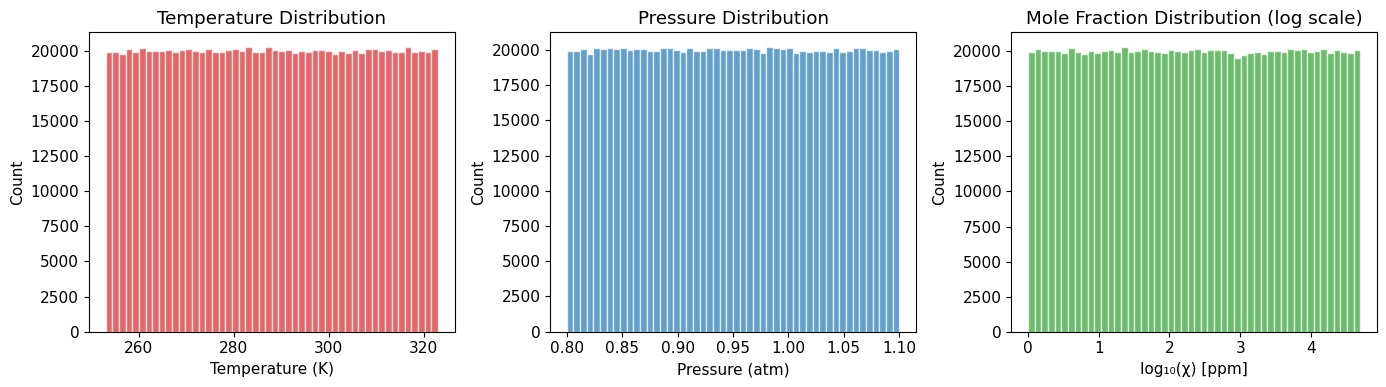

T and P: uniform. χ: log-uniform (flat in log-space → equal coverage per decade).


In [6]:
# ── Visualize the parameter distributions ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(T_all, bins=50, color='tab:red', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Count')
axes[0].set_title('Temperature Distribution')

axes[1].hist(P_all, bins=50, color='tab:blue', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Pressure (atm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Pressure Distribution')

axes[2].hist(np.log10(xi_all * 1e6), bins=50, color='tab:green', alpha=0.7, edgecolor='white')
axes[2].set_xlabel('log₁₀(χ) [ppm]')
axes[2].set_ylabel('Count')
axes[2].set_title('Mole Fraction Distribution (log scale)')

plt.tight_layout()
plt.show()

print("T and P: uniform. χ: log-uniform (flat in log-space → equal coverage per decade).")

### Why 1 Million Scans?

The original project used ~50K training scans. We scale to 1M because:

1. **Better coverage** — With 3 free parameters (T, P, $\chi$) spanning wide ranges, 1M samples provides denser coverage of the parameter space.
2. **CNN generalization** — Deep networks benefit from more training data, especially when the mapping is nonlinear (absorbance saturates at high $\chi$, line shapes change with T and P).
3. **Log-uniform $\chi$ sampling** — Half our samples cover 1–~220 ppm (low concentrations). With only 50K total scans, the low-$\chi$ regime would be sparsely covered.

---
## 5.2 — Parallelizing with Multiprocessing

Each scan is independent — the forward model for scan $i$ doesn't depend on scan $j$. This is an **embarrassingly parallel** problem, ideal for `multiprocessing.Pool`.

### Why CPU-bound?

The bottleneck is HAPI's `absorptionCoefficient_Voigt()`, which computes Faddeeva functions using NumPy on the CPU. HAPI wasn't designed for GPU execution. (Section 5.5 explores a GPU alternative.)

### Strategy

1. Split the 1M scans into **batches** (chunks)
2. Each worker process generates a batch of scans
3. Results are written **incrementally** to an HDF5 file to avoid holding 1M scans in memory

In [7]:
def generate_single_scan(args):
    """
    Generate a single detector scan for given (T, P, χ).
    
    Worker function for multiprocessing — must be a top-level function.
    HAPI must be initialized in each worker process.
    
    Parameters
    ----------
    args : tuple of (index, T, P, xi)
    
    Returns
    -------
    dict with keys: 'index', 'I_t', 'alpha_spec', 'T', 'P', 'xi'
    """
    idx, T, P, xi = args
    
    with suppress_stdout():
        result = simulate_detector_scan_fast(T, P, xi)
    
    return {
        'index': idx,
        'I_t': result['I_t'].astype(np.float32),
        'alpha_spec': result['alpha_spec'].astype(np.float32),
        'T': T,
        'P': P,
        'xi': xi
    }


print("✅ Worker function defined")

✅ Worker function defined


In [8]:
def init_worker():
    """
    Initialize HAPI in each worker process.
    
    multiprocessing spawns new processes that don't inherit the parent's
    HAPI state, so each worker must call db_begin() independently.
    """
    import hapi
    hapi.db_begin(str(HITRAN_DIR))


print("✅ Worker initializer defined")

✅ Worker initializer defined


In [9]:
def generate_dataset(T_arr, P_arr, xi_arr, output_path, batch_size=1000,
                     n_workers=None, sample_rate=250_000, f=10):
    """
    Generate the full dataset using multiprocessing, writing to HDF5 incrementally.
    
    Parameters
    ----------
    T_arr, P_arr, xi_arr : ndarray
        Parameter arrays (length N)
    output_path : str or Path
        Path to output HDF5 file
    batch_size : int
        Number of scans per batch (controls memory usage)
    n_workers : int or None
        Number of parallel workers (None = cpu_count)
    
    Returns
    -------
    elapsed : float   Total generation time in seconds
    """
    N = len(T_arr)
    n_samples_per_scan = int(sample_rate / f)  # 25,000
    
    if n_workers is None:
        n_workers = mp.cpu_count()
    
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # ── Determine spectrum grid size ───────────────────────
    nu_test, a_test = generate_absorbance_spectrum(296, 1.0, 0.01)
    n_spec_points = len(nu_test)
    
    print(f"Generating {N:,} scans")
    print(f"  Workers      : {n_workers}")
    print(f"  Batch size   : {batch_size:,}")
    print(f"  Samples/scan : {n_samples_per_scan:,}")
    print(f"  Spectrum pts : {n_spec_points:,}")
    print(f"  Output       : {output_path}")
    print()
    
    # ── Create HDF5 file with pre-allocated datasets ──────
    with h5py.File(output_path, 'w') as hf:
        # Store the wavenumber grid once (shared across all scans)
        hf.create_dataset('nu', data=nu_test.astype(np.float32))
        
        # Pre-allocate large datasets
        ds_It = hf.create_dataset(
            'I_t', shape=(N, n_samples_per_scan), dtype=np.float32,
            chunks=(min(batch_size, N), n_samples_per_scan)
        )
        ds_alpha = hf.create_dataset(
            'a', shape=(N, n_spec_points), dtype=np.float32,
            chunks=(min(batch_size, N), n_spec_points)
        )
        ds_T  = hf.create_dataset('T', shape=(N,), dtype=np.float32)
        ds_P  = hf.create_dataset('P', shape=(N,), dtype=np.float32)
        ds_xi = hf.create_dataset('xi', shape=(N,), dtype=np.float32)
        
        # Store metadata
        hf.attrs['n_scans'] = N
        hf.attrs['sample_rate'] = sample_rate
        hf.attrs['scan_frequency'] = f
        hf.attrs['path_length_cm'] = PATH_LENGTH
        hf.attrs['nu_min'] = NU_MIN
        hf.attrs['nu_max'] = NU_MAX
        hf.attrs['nu_step'] = NU_STEP
        
        # ── Generate in batches ────────────────────────────
        n_batches = (N + batch_size - 1) // batch_size
        t_start = time.perf_counter()
        
        pbar = tqdm(total=N, desc='Generating scans', unit='scan')
        
        for b in range(n_batches):
            i_start = b * batch_size
            i_end = min(i_start + batch_size, N)
            batch_n = i_end - i_start
            
            # Build argument list for this batch
            args_list = [
                (i, T_arr[i], P_arr[i], xi_arr[i])
                for i in range(i_start, i_end)
            ]
            
            # Run batch in parallel
            # NOTE: We use 'fork' context because macOS defaults to 'spawn',
            # which can't pickle functions defined in Jupyter notebooks.
            ctx = mp.get_context('fork')
            with ctx.Pool(processes=n_workers, initializer=init_worker) as pool:
                results = pool.map(generate_single_scan, args_list)
            
            # Write results to HDF5
            for r in results:
                idx = r['index']
                ds_It[idx]    = r['I_t']
                ds_alpha[idx] = r['alpha_spec']
                ds_T[idx]     = r['T']
                ds_P[idx]     = r['P']
                ds_xi[idx]    = r['xi']
            
            pbar.update(batch_n)
        
        pbar.close()
    
    elapsed = time.perf_counter() - t_start
    
    file_size_gb = output_path.stat().st_size / 1e9
    print(f"\n✅ Dataset generation complete!")
    print(f"   Time elapsed : {elapsed:.1f}s ({elapsed/3600:.2f} hours)")
    print(f"   Throughput   : {N/elapsed:.0f} scans/second")
    print(f"   File size    : {file_size_gb:.2f} GB")
    print(f"   Output       : {output_path}")
    
    return elapsed


print("✅ generate_dataset() defined")

✅ generate_dataset() defined


### HDF5 Dataset Structure

The output file has the following layout:

| Key   | Shape              | Dtype   | Description                       |
|-------|--------------------|---------|-----------------------------------|
| `nu`  | (num_points,)      | float32 | Wavenumber grid (cm⁻¹)            |
| `I_t` | (N, 25000)         | float32 | Transmitted intensity traces       |
| `a`   | (N, num_spec_pts)  | float32 | Absorbance spectra                 |
| `T`   | (N,)               | float32 | Temperature (K)                    |
| `P`   | (N,)               | float32 | Pressure (atm)                     |
| `xi`  | (N,)               | float32 | Mole fraction (dimensionless)      |

We store both `I_t` (detector trace — the CNN's input) and `a` (absorbance spectrum — useful for diagnostics and alternative model inputs).

---
## 5.3 — Running the Generation

### Test Run: Small Batch

Before committing to 1M scans, let's generate a small test batch and verify correctness.

In [10]:
# ── Small test run: 100 scans ──────────────────────────────
N_TEST = 100
T_test, P_test, xi_test = sample_parameters(N_TEST, seed=99)

test_path = DATASET_DIR / 'dataset_test_100.h5'

elapsed_test = generate_dataset(
    T_test, P_test, xi_test,
    output_path=test_path,
    batch_size=50,
    n_workers=min(4, mp.cpu_count())
)

{'air': 1.0}
0.097192 seconds elapsed for abscoef; nlines = 501
Generating 100 scans
  Workers      : 4
  Batch size   : 50
  Samples/scan : 25,000
  Spectrum pts : 3,001
  Output       : /Users/davidvs/RedwoodLabs/methane-ml-course/data/datasets/dataset_test_100.h5



Generating scans:   0%|          | 0/100 [00:00<?, ?scan/s]

Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran
Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran



CH4_4383_4386Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran
CH4_4383_4386

CH4_4383_4386
Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran

                     Lines parsed: 501CH4_4383_4386
                     Lines parsed: 501

                     Lines parsed: 501
                     Lines parsed: 501
Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran

Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran
CH4_4383_4386
Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran

CH4_4383_4386

CH4_4383_4386
Using /Users/davidvs/RedwoodLabs/methane-ml-course/data/hitran

                     Lines parsed: 501CH4_4383_4386
                     Lines parsed: 501
                     Lines parsed: 501

                     Lines parsed: 501

✅ Dataset generation complete!
   Time elapsed : 2.9s (0.00 hou

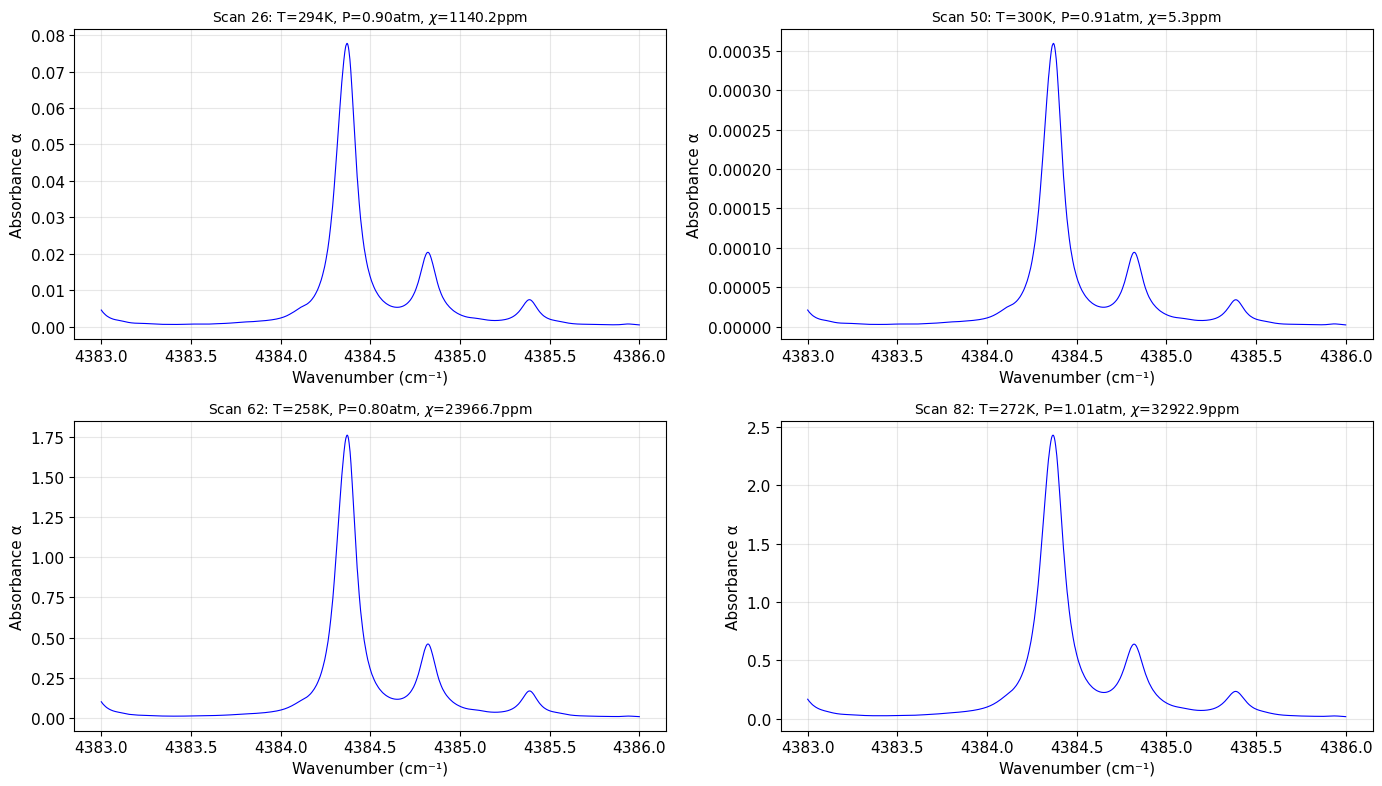

Spot-check complete — verify that peaks scale with χ and shapes vary with T, P.


In [11]:
# ── Spot-check: load and plot a few random scans ───────────
with h5py.File(test_path, 'r') as hf:
    nu = hf['nu'][:]
    
    # Pick 4 random scans
    rng = np.random.default_rng(0)
    check_indices = rng.choice(N_TEST, size=4, replace=False)
    check_indices.sort()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    for ax, idx in zip(axes.flat, check_indices):
        I_t = hf['I_t'][idx]
        a   = hf['a'][idx]
        T_i = hf['T'][idx]
        P_i = hf['P'][idx]
        xi_i = hf['xi'][idx]
        
        # Plot absorbance spectrum
        ax.plot(nu, a, 'b-', linewidth=0.8)
        ax.set_xlabel('Wavenumber (cm⁻¹)')
        ax.set_ylabel('Absorbance α')
        ax.set_title(
            f'Scan {idx}: T={T_i:.0f}K, P={P_i:.2f}atm, '
            f'$\\chi$={xi_i*1e6:.1f}ppm',
            fontsize=10
        )
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Spot-check complete — verify that peaks scale with χ and shapes vary with T, P.")

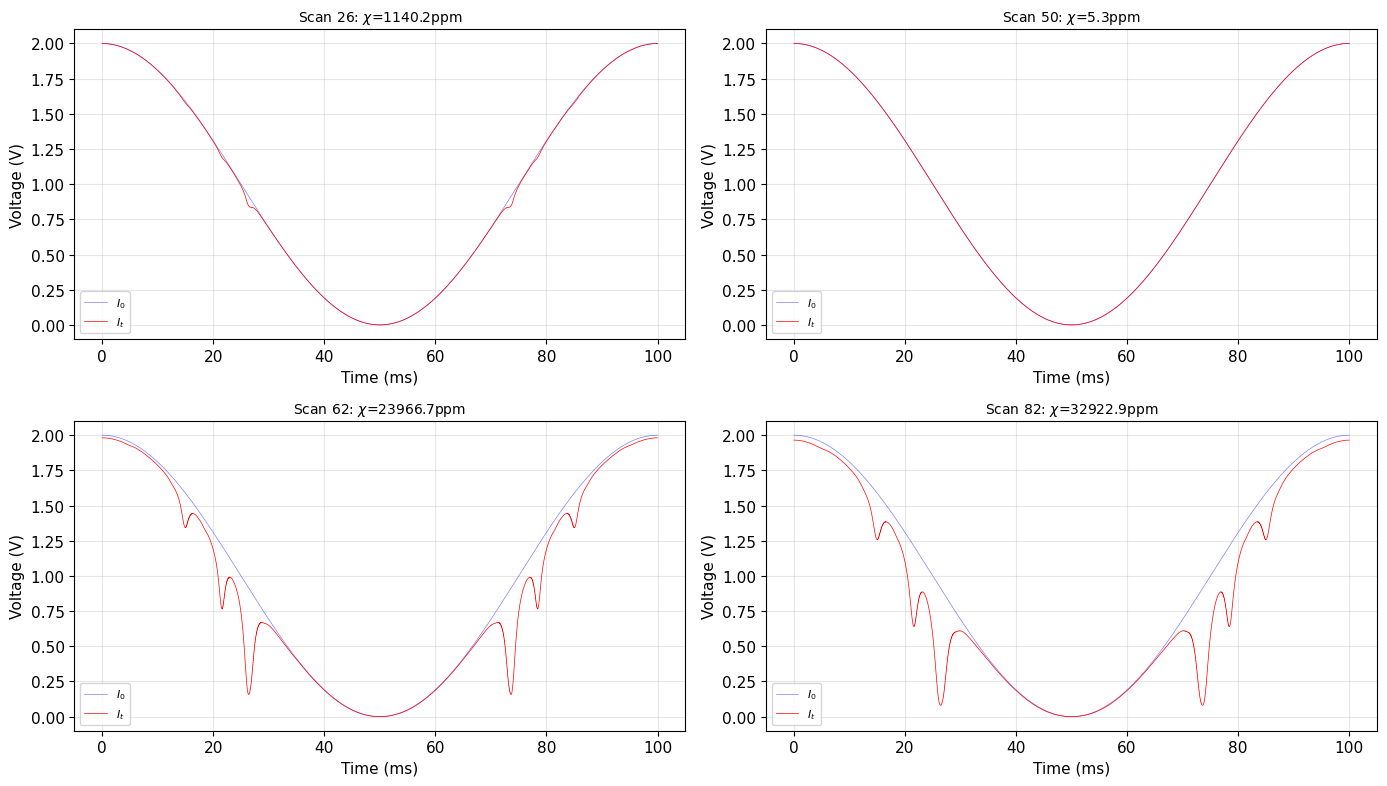

Verify: absorption dips are deeper at higher χ, I_t ≤ I_0 everywhere.


In [12]:
# ── Spot-check: detector traces ───────────────────────────
with h5py.File(test_path, 'r') as hf:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    sample_rate = 250_000
    f_scan = 10
    n_pts = hf['I_t'].shape[1]
    t_scan = np.linspace(0, 1/f_scan, n_pts, endpoint=False)
    
    for ax, idx in zip(axes.flat, check_indices):
        I_t  = hf['I_t'][idx]
        T_i  = hf['T'][idx]
        P_i  = hf['P'][idx]
        xi_i = hf['xi'][idx]
        
        # Reconstruct I_0 for reference
        I_0 = np.cos(2 * np.pi * f_scan * t_scan) + 1.0
        
        ax.plot(t_scan * 1e3, I_0, 'b-', linewidth=0.5, alpha=0.5, label='$I_0$')
        ax.plot(t_scan * 1e3, I_t, 'r-', linewidth=0.5, label='$I_t$')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Voltage (V)')
        ax.set_title(
            f'Scan {idx}: $\\chi$={xi_i*1e6:.1f}ppm',
            fontsize=10
        )
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Verify: absorption dips are deeper at higher χ, I_t ≤ I_0 everywhere.")

### Extrapolate: How Long Will 1M Take?

Use the test run to estimate the full generation time.

In [13]:
# ── Extrapolate timing ─────────────────────────────────────
scans_per_sec = N_TEST / elapsed_test
est_time_1M = N_SCANS / scans_per_sec

print(f"Test run: {N_TEST} scans in {elapsed_test:.1f}s → {scans_per_sec:.1f} scans/sec")
print(f"\nEstimated time for {N_SCANS:,} scans:")
print(f"  {est_time_1M:.0f} seconds")
print(f"  {est_time_1M/60:.1f} minutes")
print(f"  {est_time_1M/3600:.2f} hours")

Test run: 100 scans in 2.9s → 35.0 scans/sec

Estimated time for 1,000,000 scans:
  28602 seconds
  476.7 minutes
  7.94 hours


### Full Generation: 1 Million Scans

⚠️ **This cell will take a while, maybe hours** — see the estimate above. Grab some coffee.

Progress is tracked with `tqdm`. If you need to interrupt and resume, see the note below the cell.

In [ ]:
# ── Generate the full 1M dataset ──────────────────────────
dataset_path = DATASET_DIR / 'dataset_1M.h5'

elapsed_full = generate_dataset(
    T_all, P_all, xi_all,
    output_path=dataset_path,
    batch_size=1000,
    n_workers=mp.cpu_count()
)

> **Resuming after interruption:** If generation is interrupted, you'll need to re-run from the top. The HDF5 file is created fresh each time (`'w'` mode). For a more robust pipeline with checkpointing, you could modify `generate_dataset()` to accept a `start_index` parameter and open the file in `'a'` mode — but for a one-time generation job, simply re-running is simpler.

In [25]:
# ── Verify dataset shape ──────────────────────────
import h5py

with h5py.File(DATASET_DIR / 'dataset_1M.h5', 'r') as hf:
    print("Datasets:")
    for key in hf.keys():
        print(f"  {key}: shape={hf[key].shape}, dtype={hf[key].dtype}")
    print(f"\nExpected 1,000,000 scans — got {hf['T'].shape[0]:,}")

Datasets:
  I_t: shape=(1000000, 25000), dtype=float32
  P: shape=(1000000,), dtype=float32
  T: shape=(1000000,), dtype=float32
  a: shape=(1000000, 3001), dtype=float32
  nu: shape=(3001,), dtype=float32
  xi: shape=(1000000,), dtype=float32

Expected 1,000,000 scans — got 1,000,000


---
## 5.4 — Dataset Normalization Strategy

Neural networks train more effectively when inputs and targets are on comparable scales. We normalise every feature by its **global maximum**, storing that single value in the HDF5 file for use during training.

### Strategy

| Feature | Normalization | Form | Rationale |
|---------|--------------|------|-----------|
| Absorbance spectrum `α` | Element-wise max | α_norm[k] = α_scan[k] / α_global_max | Preserves spectral shape; all values → [0, 1] |
| Temperature `T` | Scalar max | T_norm = T_scan / T_global_max | Single value broadcast across spectral points |
| Pressure `P` | Scalar max | P_norm = P_scan / P_global_max | Single value broadcast across spectral points |
| Mole fraction `χ` (target) | Scalar max | χ_norm = χ_scan / χ_global_max | Normalised regression target → [0, 1] |

The CNN receives a **3 × num_spec_points** input tensor per scan:
- **Channel 0:** full normalised absorbance spectrum (element-wise)
- **Channel 1:** T_norm broadcast to all spectral points
- **Channel 2:** P_norm broadcast to all spectral points


In [26]:
from tqdm.notebook import tqdm

def compute_and_store_normalization(dataset_path):
    """
    Compute normalization statistics from the dataset and store them
    as HDF5 attributes for use during training.

    Normalization convention:
        α_norm[k] = α_scan[k] / α_global_max   (element-wise over spectrum)
        T_norm     = T_scan    / T_global_max   (scalar)
        P_norm     = P_scan    / P_global_max   (scalar)
        χ_norm     = χ_scan    / χ_global_max   (scalar, regression target)

    α_global_max is the single largest absorbance value across all scans
    and all spectral points — preserving the spectral shape after division.
    We scan the absorbance data in chunks to avoid loading it all into memory.
    """
    print("Computing normalization statistics...")

    with h5py.File(dataset_path, 'a') as hf:
        N          = hf['a'].shape[0]
        chunk_size = 10_000
        n_chunks   = (N + chunk_size - 1) // chunk_size

        # ── Absorbance: global max over all scans AND all spectral points ─
        a_global_max = -np.inf
        with tqdm(total=N, desc="  α global max", unit="scans", unit_scale=True) as pbar:
            for i in range(0, N, chunk_size):
                chunk        = hf['a'][i:i+chunk_size]   # shape: (chunk, num_pts)
                a_global_max = max(a_global_max, chunk.max())
                pbar.update(chunk.shape[0])

        # ── T, P, χ global maxima ────────────────────────────────────────
        with tqdm(total=3, desc="  T / P / χ maxima", unit="arrays", leave=False) as pbar:
            T_global_max  = float(hf['T'][:].max());  pbar.update(1)
            P_global_max  = float(hf['P'][:].max());  pbar.update(1)
            xi_global_max = float(hf['xi'][:].max()); pbar.update(1)

        # ── Store normalization parameters ───────────────────────────────
        hf.attrs['a_global_max']  = float(a_global_max)
        hf.attrs['T_global_max']  = T_global_max
        hf.attrs['P_global_max']  = P_global_max
        hf.attrs['xi_global_max'] = xi_global_max

    print(f"\n  α global max : {a_global_max:.6f}")
    print(f"  T global max : {T_global_max:.1f} K")
    print(f"  P global max : {P_global_max:.4f} atm")
    print(f"  χ global max : {xi_global_max*1e6:.2f} ppm")
    print(f"\n✅ Normalization stats stored in HDF5 attributes.")

print("✅ compute_and_store_normalization() defined")

✅ compute_and_store_normalization() defined


In [28]:
# ── Compute normalization for the full dataset ─────────────
dataset_path = DATASET_DIR / 'dataset_1M.h5'
compute_and_store_normalization(dataset_path)

Computing normalization statistics...


  α global max:   0%|          | 0.00/1.00M [00:00<?, ?scans/s]

  T / P / χ maxima:   0%|          | 0/3 [00:00<?, ?arrays/s]


  α global max : 3.885921
  T global max : 323.0 K
  P global max : 1.1000 atm
  χ global max : 49999.96 ppm

✅ Normalization stats stored in HDF5 attributes.


In [29]:
# ── Verify: read back attributes ──────────────────────────
with h5py.File(dataset_path, 'r') as hf:
    print("HDF5 file contents:")
    print(f"  Datasets: {list(hf.keys())}")
    for key in hf.keys():
        print(f"    {key}: shape={hf[key].shape}, dtype={hf[key].dtype}")
    
    print(f"\n  Attributes:")
    for attr_name, attr_val in hf.attrs.items():
        print(f"    {attr_name}: {attr_val}")

HDF5 file contents:
  Datasets: ['I_t', 'P', 'T', 'a', 'nu', 'xi']
    I_t: shape=(1000000, 25000), dtype=float32
    P: shape=(1000000,), dtype=float32
    T: shape=(1000000,), dtype=float32
    a: shape=(1000000, 3001), dtype=float32
    nu: shape=(3001,), dtype=float32
    xi: shape=(1000000,), dtype=float32

  Attributes:
    P_global_max: 1.0999999046325684
    T_global_max: 322.9999694824219
    a_global_max: 3.8859214782714844
    n_scans: 1000000
    nu_max: 4386.0
    nu_min: 4383.0
    nu_step: 0.001
    path_length_cm: 100.0
    sample_rate: 250000
    scan_frequency: 10
    xi_global_max: 0.04999995604157448


### How Normalization Will Be Applied During Training

In Module 6, the `Dataset` class will apply these transformations on-the-fly:

```python
# Read global maxima stored with the dataset
a_global_max  = hf.attrs['a_global_max']
T_global_max  = hf.attrs['T_global_max']
P_global_max  = hf.attrs['P_global_max']
xi_global_max = hf.attrs['xi_global_max']

# Normalise each sample
a_norm  = a_scan / a_global_max    # element-wise over spectrum → [0, 1]
T_norm  = T_scan / T_global_max    # scalar                     → [0, 1]
P_norm  = P_scan / P_global_max    # scalar                     → [0, 1]
xi_norm = xi_scan / xi_global_max  # scalar target              → [0, 1]

# Assemble CNN input tensor: shape (3, num_spec_points)
# Channel 0: a_norm                         — full normalised spectrum
# Channel 1: T_norm broadcast to all points — scalar condition
# Channel 2: P_norm broadcast to all points — scalar condition
# Target: xi_norm
input_tensor = np.stack([
    a_norm,
    np.full_like(a_norm, T_norm),
    np.full_like(a_norm, P_norm),
])  # shape: (3, num_spec_points)
```

This keeps the normalization parameters stored *with* the dataset, so training code can read them directly from the HDF5 file.


---
## Summary

### What We Accomplished

1. **Designed the parameter space** — T (253–323 K), P (0.8–1.1 atm), $\chi$ (1–50,000 ppm, log-uniform)
2. **Parallelized generation** — `multiprocessing.Pool` with incremental HDF5 writes
3. **Generated 1M scans** — Full forward model at scale, stored in `dataset_1M.h5`

### What's Next

In **Module 6**, we'll build the 1D-CNN in PyTorch and set up DataLoaders to read from this HDF5 dataset. You'll need to upload `dataset_1M.h5` to the GPU droplet for training.

---
**Module 5 Complete!**

You now have a `dataset_1M.h5` file with 1M simulated detector scans. Upload it to your AMD GPU droplet to begin training in Module 6.